# Aliasing and Copying

In [1]:
import sys
from pathlib import Path

# Find project root by looking for _config.yml
current = Path.cwd()
for parent in [current, *current.parents]:
    if (parent / '_config.yml').exists():
        project_root = parent
        break
else:
    project_root = Path.cwd().parent.parent

# Add project root to path
sys.path.insert(0, str(project_root))

# Import shared teaching helpers and cell magics
from shared import thinkpython, diagram, jupyturtle, structshape
from shared.download import download


```{contents}
:local:
:depth: 2
```

A variable does not hold a list directly; it holds a reference to a list object. This section looks at what that means: when two names refer to the same object, how a change made through one name shows up through the other, and how to make copies that are truly independent.

The examples use lists, but the same rules apply to every mutable collection, including sets, which you will meet in Section 7.4. Tuples, covered in Section 6.3, are immutable, so a change can never show up through an alias of a tuple itself.

The table below summarizes the three cases:

| Concept      | Outer Object | Inner Objects | Syntax                    | Changes affect original? |
| ------------ | ------------ | ------------- | ------------------------- | ------------------------ |
| Aliasing     | **Same**     | **Same**      | `b = a`                   | Yes                      |
| Shallow Copy | **New**      | **Same**      | `[:]`, `copy()`, `list()` | Sometimes (when nested)  |
| Deep Copy    | **New**      | **New**       | `copy.deepcopy()`         | No                       |


## Objects and Values

If we run these assignment statements:

In [2]:
a = 'banana'
b = 'banana'

We know that `a` and `b` both refer to a string, but we don't know whether they refer to the *same* string. 
There are two possible states, shown in the following figure.

In [3]:
from shared.diagram import Bbox, Binding, Frame, Stack, Value, adjust, diagram

s = 'banana'
bindings = [Binding(Value(name), Value(repr(s))) for name in 'ab']
frame1 = Frame(bindings, dy=-0.25)

binding1 = Binding(Value('a'), Value(repr(s)), dy=-0.11)
binding2 = Binding(Value('b'), draw_value=False, dy=0.11)
frame2 = Frame([binding1, binding2], dy=-0.25)

stack = Stack([frame1, frame2], dx=1.7, dy=0)


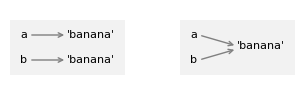

In [4]:
width, height, x, y = [2.85, 0.76, 0.17, 0.51]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)
# adjust(x, y, bbox)

In the diagram on the left, `a` and `b` refer to two different objects that have the
same value. In the diagram on the right, they refer to the same object.
To check whether two variables refer to the same object, you can use the `is` operator.

In [5]:
a = 'banana'
b = 'banana'
a is b

True

In this example, Python only created one string object, and both `a`
and `b` refer to it.
Python sometimes reuses one object for identical short strings, an optimization called *interning*, so `a is b` happens to be `True` here. Don't rely on it: use `==` to compare values and `is` only to check whether two names refer to the same object.

But when you create two lists, you get two objects.

In [6]:
a = [1, 2, 3]
b = [1, 2, 3]
a is b

False

So the state diagram looks like this.

In [7]:
t = [1, 2, 3]
binding1 = Binding(Value('a'), Value(repr(t)))
binding2 = Binding(Value('b'), Value(repr(t)))
frame = Frame([binding1, binding2], dy=-0.25)

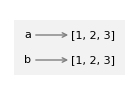

In [8]:
width, height, x, y = [1.16, 0.76, 0.21, 0.51]
ax = diagram(width, height)
bbox = frame.draw(ax, x, y)
# adjust(x, y, bbox)

In this case we would say that the two lists are **equivalent**, because they have the same elements, but not **identical**, because they are not the same object. 
If two objects are identical, they are also equivalent, but if they are equivalent, they are not necessarily identical.

In [9]:
### EXERCISE: Objects and Values *(basic)*
x = [10, 20, 30]
y = x
z = [10, 20, 30]
# 1. Check if x and y refer to the same object using "is"
# 2. Check if x and z have the same value using "=="
# 3. Check if x and z refer to the same object using "is"
### Your code starts here:



### Your code ends here.

In [10]:
### Solution
x = [10, 20, 30]
y = x
z = [10, 20, 30]

same_object_xy = x is y
same_value_xz = x == z
same_object_xz = x is z

print(f"x is y: {same_object_xy}")  # True - same object (alias)
print(f"x == z: {same_value_xz}")   # True - same value (equivalent)
print(f"x is z: {same_object_xz}")  # False - different objects

x is y: True
x == z: True
x is z: False


## Aliasing

Aliasing occurs when two or more variables point to the same object in memory. When you do a **variable assignment** using `=` in Python, you're not **copying** the object—you're creating another variable that points to the **same object**. This second variable is an **alias**.

If `a` refers to an object and you assign `b = a`, then both variables refer to the same object.

In [11]:
a = [1, 2, 3]
b = a
b is a

True

So the state diagram looks like this.

In [12]:
t = [1, 2, 3]
binding1 = Binding(Value('a'), Value(repr(t)), dy=-0.11)
binding2 = Binding(Value('b'), draw_value=False, dy=0.11)
frame = Frame([binding1, binding2], dy=-0.25)

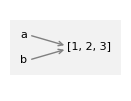

In [13]:
width, height, x, y = [1.11, 0.81, 0.17, 0.56]
ax = diagram(width, height)
bbox = frame.draw(ax, x, y)
# adjust(x, y, bbox)

The association of a variable with an object is called a **reference**.
In this example, there are two references to the same object.

An object with more than one reference has more than one name, so we say the object is **aliased**.
If the aliased object is mutable, changes made with one name affect the other.
In this example, if we change the object `b` refers to, we are also changing the object `a` refers to.

In [14]:
b[0] = 5
a

[5, 2, 3]

So we would say that `a` "sees" this change.
Although this behavior can be useful, it is error-prone.
In general, it is safer to avoid aliasing when you are working with mutable objects.

You can confirm that two names share one object with `is`, or by comparing their `id()` values, which identify an object while it exists:

In [15]:
# Aliasing: both variables point to the same list
original = [1, 2, 3, 4, 5]
alias = original    # NOT a copy!

alias[0] = 999      # Modify through the alias

print("Original:\t", original)  # check to see if original is modified
print("Alias:\t\t", alias)        

print("Same id?\t", id(original) == id(alias))  # True

print("Same object?\t", original is alias)  # True

Original:	 [999, 2, 3, 4, 5]
Alias:		 [999, 2, 3, 4, 5]
Same id?	 True
Same object?	 True


For immutable objects like strings, aliasing is not as much of a problem.
In this example:

In [16]:
c = 'banana'
d = 'banana'

It almost never makes a difference whether `c` and `d` refer to the same
string or not.

Reassigning a name is different from modifying an object. With immutable strings, reassigning one name creates a new object and never affects the other name:

In [17]:
# Contrast with immutable strings
name1 = "Chen"
name2 = name1                         # alias: both names refer to the same string
print("Same object?", name1 is name2)  # True

name2 = "Alice"                       # reassignment: name2 now refers to a new string
print(name1, name2)                   # name1 is unchanged
print("Same object?", name1 is name2)  # False

Same object? True
Chen Alice
Same object? False


Aliasing is useful for efficiency (no copying needed), but can cause unexpected behavior if you modify mutable objects, thinking you have independent copies.

In [18]:
### EXERCISE: Aliasing *(applied)*
a = [1, 2, 3]
# 1. Create an alias b that points to the same list as a
# 2. Modify the list through b by changing the first element to 99
# 3. Create a true copy c using slicing
# 4. Modify c and observe that a remains unchanged
### Your code starts here:



### Your code ends here.

In [19]:
### Solution
a = [1, 2, 3]
b = a  # alias
b[0] = 99

print(f"a after aliasing: {a}")
print(f"b: {b}")
print(f"Same object? {a is b}")

c = a[:]  # true copy
c[1] = 777

print(f"\na after copying: {a}")
print(f"c: {c}")
print(f"Same object? {a is c}")

a after aliasing: [99, 2, 3]
b: [99, 2, 3]
Same object? True

a after copying: [99, 2, 3]
c: [99, 777, 3]
Same object? False


## List Arguments in Functions

When you pass a list to a function, the function gets a reference to the
list. If the function modifies the list, the caller sees the change. For
example, `pop_first` uses the list method `pop` to remove the first element from a list.

In [20]:
def pop_first(lst):
    return lst.pop(0)

We can use it like this.

In [21]:
letters = ['a', 'b', 'c']
pop_first(letters)

'a'

The return value is the first element, which has been removed from the list -- as we can see by displaying the modified list.

In [22]:
letters

['b', 'c']

In this example, the parameter `lst` and the variable `letters` are aliases for the same object, so the state diagram looks like this:

In [23]:
from shared.diagram import make_list, Binding, Value

lst = make_list('abc', dy=-0.3, offsetx=0.1)
binding1 = Binding(Value('letters'), draw_value=False)
frame1 = Frame([binding1], name='__main__', loc='left')

binding2 = Binding(Value('lst'), draw_value=False, dx=0.61, dy=0.35)
frame2 = Frame([binding2], name='pop_first', loc='left', offsetx=0.08)

stack = Stack([frame1, frame2], dx=-0.3, dy=-0.5)

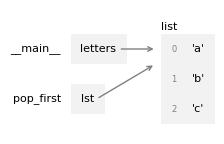

In [24]:
width, height, x, y = [2.04, 1.24, 1.06, 0.85]
ax = diagram(width, height)
bbox1 = stack.draw(ax, x, y)
bbox2 = lst.draw(ax, x+0.5, y)
bbox = Bbox.union([bbox1, bbox2])
# adjust(x, y, bbox)

Passing a reference to an object as an argument to a function creates a form of aliasing.
If the function modifies the object, those changes persist after the function is done.

In [25]:
### EXERCISE: List Arguments in Functions *(applied)*
def add_item(lst, item):
    """Add item to list and return the list"""
    lst.append(item)
    return lst

# 1. Create a list with [1, 2, 3], call it original
# 2. Call add_item with your list and the value 4, 
#    save the result in a variable called updated
# 3. Print the original list to see if it changed after calling the function
# 4. check if original and updated refer to the same object using "is"
### Your code starts here:



### Your code ends here.

In [26]:
### Solution
def add_item(lst, item):
    """Add item to list and return the list"""
    lst.append(item)
    return lst

original = [1, 2, 3]
print(f"Original list: {original}")

updated = add_item(original, 4)
print(f"Returned list: {updated}")
print(f"Original list after function call: {original}")
print(f"Same object? {updated is original}")

Original list: [1, 2, 3]
Returned list: [1, 2, 3, 4]
Original list after function call: [1, 2, 3, 4]
Same object? True


## Shallow Copy

To create a shallow copy, you can use 
- list slicing `[:]`, 
- the `.copy()` method, 
- the `list()` function, or 
- `copy.copy()`. 

In [27]:
import copy

a = [1, 2, 3]

b = a[:]          # list slicing
b = a.copy()      # copy() method
b = list(a)       # list() function
b = copy.copy(a)  # copy module

All these methods create a new list object, but if the list contains other mutable objects (like nested lists), those nested objects are not copied—only their references are copied.

A shallow copy creates a new object while retaining references to the objects contained in the original. It only copies the top-level structure without duplicating nested elements. 

For simple **1-D lists** (containing only **immutable** objects like numbers, strings, or booleans), shallow copying works well: each copy is a new list object, as the `is` checks below show.

In [28]:
# four ways to create a shallow copy
import copy

letters = ['a', 'b', 'c', 'd']

letters_copy1 = letters[:]          # list slicing
letters_copy2 = letters.copy()      # the copy() method
letters_copy3 = list(letters)       # the list function
letters_copy4 = copy.copy(letters)  # using the copy module

print(letters_copy1)
print(letters_copy2)
print(letters_copy3)
print(letters_copy4)

print("All copies have the same contents?", letters_copy1 == letters_copy2 == letters_copy3 == letters_copy4)  # True, contents are the same
print("letters_copy1 is letters?", letters_copy1 is letters)  # False, different objects in memory
print("letters_copy2 is letters?", letters_copy2 is letters)  # False, different objects in memory
print("letters_copy3 is letters?", letters_copy3 is letters)  # False, different objects in memory
print("letters_copy4 is letters?", letters_copy4 is letters)  # False, different objects in memory

['a', 'b', 'c', 'd']
['a', 'b', 'c', 'd']
['a', 'b', 'c', 'd']
['a', 'b', 'c', 'd']
All copies have the same contents? True
letters_copy1 is letters? False
letters_copy2 is letters? False
letters_copy3 is letters? False
letters_copy4 is letters? False


In [29]:
# simpler example: shallow copy works fine for 1-D lists: Update
original = [1, 2, 3, 4, 5]
shallow = original[:]  # Creates a new list

print("Same value?\t", original == shallow)   # True
print("Same object?\t", original is shallow)  # False

# Modify the shallow copy
shallow[4] = 999
print("update shallow:\t", shallow)

print("Original:\t", original)  # Original is unchanged
print("Shallow:\t", shallow)    # Only the copy is modified


Same value?	 True
Same object?	 False
update shallow:	 [1, 2, 3, 4, 999]
Original:	 [1, 2, 3, 4, 5]
Shallow:	 [1, 2, 3, 4, 999]


However, for nested lists (lists containing other lists), shallow copy shares references to the nested objects:

In [30]:
# Using copy.copy() with nested lists
import copy
original = [[1, 2], [3, 4]]
shallow = copy.copy(original)

print("original-shallow same value?\t", original == shallow)   # True - contents are the same
print("original-shallow same object?\t", id(original) == id(shallow))  # False - different list objects

shallow[0].append(99)
print("update shallow (99):\t\t", shallow)
print("is original updated?\t\t", original)  # [[1, 2, 99], [3, 4]] - nested list affected!

print("same nested object?\t\t", shallow[0] is original[0])  # True - same nested list object

original-shallow same value?	 True
original-shallow same object?	 False
update shallow (99):		 [[1, 2, 99], [3, 4]]
is original updated?		 [[1, 2, 99], [3, 4]]
same nested object?		 True


The two outer lists are different objects, but they share the same inner lists, so a change to `shallow[0]` also shows up in `original[0]`. The same thing happens when you make a shallow copy with slicing:

In [31]:
# Using slicing with nested lists
original = [[1, 2, 3], [4, 5, 6]]
shallow = original[:]  # or original.copy()

# Modify the nested list
shallow[0][0] = 999

print("Original:", original)  # Original is also modified!
print("Shallow:", shallow)
print("Same nested object?", shallow[0] is original[0])  # True - same nested list object

Original: [[999, 2, 3], [4, 5, 6]]
Shallow: [[999, 2, 3], [4, 5, 6]]
Same nested object? True


As you can see, modifying the nested list in `shallow` also affects `original` because they share references to the same inner lists.

## Deep Copy

To create a **deep copy** that copies all nested objects recursively, use the `copy` module's `deepcopy()` function. This creates completely independent copies of all nested structures. Deep copy creates a new object and recursively copies all nested objects—everything is independent.

In [32]:
import copy

original = [[1, 2, 3], [4, 5, 6]]
deep = copy.deepcopy(original)

print("Original:", original)  # Original is unchanged
print("Deep copy:", deep)    # Only the deep copy is modified

print("original-deep same value?", original == deep)   # True - contents are the same
print("original-deep same object?", id(original) == id(deep))  # False - different list objects
print("same nested object?", deep[0] is original[0])  # False - different nested list objects

# Modify the nested list
deep[0][0] = 999

print("Original:", original)  # Original is unchanged
print("Deep copy:", deep)    # Only the deep copy is modified

Original: [[1, 2, 3], [4, 5, 6]]
Deep copy: [[1, 2, 3], [4, 5, 6]]
original-deep same value? True
original-deep same object? False
same nested object? False
Original: [[1, 2, 3], [4, 5, 6]]
Deep copy: [[999, 2, 3], [4, 5, 6]]


In [33]:
# simpler example with deep copy
import copy
original = [[1, 2], [3, 4]]
deep = copy.deepcopy(original)

print(original is deep)          # False - different outer lists

deep[0].append(99)
print(original)  # [[1, 2], [3, 4]] - original unchanged!
print(deep)      # [[1, 2, 99], [3, 4]] - only deep copy changed
print(deep[0] is original[0])    # False - different nested list objects

False
[[1, 2], [3, 4]]
[[1, 2, 99], [3, 4]]
False


In [34]:
### EXERCISE: Shallow vs. Deep Copy *(applied)*
import copy
teams = [['Ann', 'Bo'], ['Cy', 'Di']]
# 1. Make a shallow copy of teams called shallow and a deep copy called deep
# 2. Append 'Ed' to the first team in shallow
# 3. Append 'Fay' to the first team in deep
# 4. Print teams, shallow, and deep.
#    Which change shows up in teams, and why?
### Your code starts here:



### Your code ends here.

In [35]:
### Solution
import copy
teams = [['Ann', 'Bo'], ['Cy', 'Di']]

shallow = teams.copy()
deep = copy.deepcopy(teams)

shallow[0].append('Ed')
deep[0].append('Fay')

print(f"teams:   {teams}")
print(f"shallow: {shallow}")
print(f"deep:    {deep}")

# 'Ed' shows up in teams because shallow[0] and teams[0] are the same inner list.
# 'Fay' does not, because deepcopy() copied the inner lists too.

teams:   [['Ann', 'Bo', 'Ed'], ['Cy', 'Di']]
shallow: [['Ann', 'Bo', 'Ed'], ['Cy', 'Di']]
deep:    [['Ann', 'Bo', 'Fay'], ['Cy', 'Di']]


## Summary

- `==` compares values; `is` checks whether two names refer to the same object.
- Assignment creates an alias, not a copy. When the object is mutable, a change made through one name shows up through the other.
- Passing a list to a function passes a reference, so the function can modify the caller's list.
- A shallow copy (slicing, `copy()`, `list()`, or `copy.copy()`) creates a new outer list but shares any nested objects.
- `copy.deepcopy()` also copies nested objects, so the copy is fully independent.

## Further Reading

- [Objects, values and types](https://docs.python.org/3/reference/datamodel.html#objects-values-and-types), Python Language Reference
- [Why did changing list 'y' also change list 'x'?](https://docs.python.org/3/faq/programming.html#why-did-changing-list-y-also-change-list-x), Python Programming FAQ
- [`copy`: Shallow and deep copy operations](https://docs.python.org/3/library/copy.html), Python Standard Library documentation